In [3]:
%load_ext autoreload
%autoreload 2

from seek_code import SEEK
from backbone import Backbone
from concept_head import ConceptHead
from retrieval import Retrieval
from projector import Projector
from data_handler import EleHandler
from concept_head_tunneled import ConceptHeadTunneled, categorical_CE_loss, CrossedHeadNN, MultiHeadNN

from pathlib import Path
from torch.utils.data import DataLoader, Subset
import torch.nn.functional as F
import torch.nn as nn
import pandas as pd

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:

dictonary_path=Path('/data/vision/beery/scratch/antoine/CBM_reid/data_processing/data/out_apr2/image_dictonary.csv')
dictonary = pd.read_csv(dictonary_path)
dictonary

,subject_id,image,ele_id,#season,#capture,anonymized_capture_id,subject-SEEK,ele-SEEK,picture_time,preprocessed_image_path,left_ear_path,right_ear_path
0,92126812,EFA_IDU/T1000/T1000_R1/EFA_IDU_T1000_R1_IMAG00...,T1000,EFA_IDU,1,a7f15c6f92cd6028dc590ecf8dfc386476faa3b4,B00T_1E____-0000X_0S00,B00T11E8080-0000X_0S00,2015-05-22 21:31:22,/data/vision/beery/scratch/antoine/CBM_reid/pr...,NaN,NaN
1,92126813,EFA_IDU/T1000/T1000_R1/EFA_IDU_T1000_R1_IMAG00...,T1000,EFA_IDU,2,4e2838a5c2c0294128f8b72b996c2edfcf498b04,B00T11E8080-0000X00S00,B00T11E8080-0000X_0S00,2015-05-22 21:33:46,/data/vision/beery/scratch/antoine/CBM_reid/pr...,/data/vision/beery/scratch/antoine/CBM_reid/pr...,/data/vision/beery/scratch/antoine/CBM_reid/pr...
2,92126815,EFA_IDU/T1001/T1001_R1/EFA_IDU_T1001_R1_IMAG00...,T1001,EFA_IDU,2,9229c652be571b6970dd2ba7fbe104597dcc851e,B00T11E0000-0000X_0S00,B00T11E____-5000X_0S00,2015-05-22 21:32:50,/data/vision/beery/scratch/antoine/CBM_reid/pr...,/data/vision/beery/scratch/antoine/CBM_reid/pr...,NaN
3,92126816,EFA_IDU/T1001/T1001_R1/EFA_IDU_T1001_R1_IMAG00...,T1001,EFA_IDU,3,d29ac1e2a0c9da2f40c3f2e1dae60aff100aa042,B00T11E____-0040X_0S00,B00T11E____-5000X_0S00,2015-05-22 21:32:51,/data/vision/beery/scratch/antoine/CBM_reid/pr...,/data/vision/beery/scratch/antoine/CBM_reid/pr...,NaN
4,92126817,EFA_IDU/T1001/T1001_R1/EFA_IDU_T1001_R1_IMAG00...,T1001,EFA_IDU,4,f73d21ecc60aaf4e940a02283aaeb3ffb4604cee,C00T1_E____-4000X_0S0_,B00T11E____-5000X_0S00,2015-05-22 21:32:52,/data/vision/beery/scratch/antoine/CBM_reid/pr...,/data/vision/beery/scratch/antoine/CBM_reid/pr...,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
8439,92306374,EFA_IDI/F1000/F1000_R1/EFA_IDI_F1000_R1_IMAG00...,F1000,EFA_IDI,8,f31a41505f66afe04009f5382c254d915f6858f8,B00T11E0000-0000X00S00,B00T11E0000-0000X0_S00,2013-08-17 16:46:01,/data/vision/beery/scratch/antoine/CBM_reid/pr...,/data/vision/beery/scratch/antoine/CBM_reid/pr...,/data/vision/beery/scratch/antoine/CBM_reid/pr...
8440,92306375,EFA_IDI/F1000/F1000_R1/EFA_IDI_F1000_R1_IMAG00...,F1000,EFA_IDI,9,eda8c2c3d7b5f94ca83e77374ed76058ca05ae06,B00T11E0000-3000X00S00,B00T11E0000-0000X0_S00,2013-08-17 16:46:04,/data/vision/beery/scratch/antoine/CBM_reid/pr...,/data/vision/beery/scratch/antoine/CBM_reid/pr...,/data/vision/beery/scratch/antoine/CBM_reid/pr...
8441,92306418,EFA_IDI/F1000/F1000_R1/EFA_IDI_F1000_R1_IMAG00...,F1000,EFA_IDI,10,9b8001c9c0ba19469b383c0f5e08f1bc0ff70638,B00T11E0000-____X0_S00,B00T11E0000-0000X0_S00,2013-08-17 16:46:35,/data/vision/beery/scratch/antoine/CBM_reid/pr...,NaN,/data/vision/beery/scratch/antoine/CBM_reid/pr...
8442,92306424,EFA_IDI/F1000/F1000_R1/EFA_IDI_F1000_R1_IMAG00...,F1000,EFA_IDI,11,383b7a07da8ba0c646b712e4abdb7a90ac2976dc,B00T1_E0000-____X0_S00,B00T11E0000-0000X0_S00,2013-08-17 16:47:24,/data/vision/beery/scratch/antoine/CBM_reid/pr...,NaN,/data/vision/beery/scratch/antoine/CBM_reid/pr...


In [5]:
# Load the YOLOv5 model for ear detection
import torch
import torchvision.transforms as T
ear_detector = torch.hub.load("ultralytics/yolov5", "custom", 
                              path='/data/vision/beery/scratch/antoine/CBM_reid/weights/ear_YOLOv5_n.pt')
ear_detector.to('cuda')

# Define transformation for ears
ear_transform = T.Compose([
    T.Resize((224, 224)),  # Resize to 224x224
    T.ToTensor(),
    T.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
])

def crop_ears(original_image):
    """
    Input: a non-transformed PIL image
    Output: a tuple (left_ear, right_ear) as **normalized tensors** (or None if missing)
    """
    with torch.inference_mode():
        # Run inference with the YOLOv5 ear detector
        output = ear_detector(original_image)

        # Extract bounding boxes and ear side labels
        xyxy = output.xyxy[0].tolist()
        ear_sides = [output.names[int(det[-1])] for det in output.pred[0].tolist()]

        # Initialize empty slots for cropped ears
        left_ear, right_ear = None, None

        # Process detected ears
        for i, (box, side) in enumerate(zip(xyxy, ear_sides)):
            x_min, y_min, x_max, y_max = map(int, box[:4])

            # Crop ear
            cropped_ear = original_image.crop((x_min, y_min, x_max, y_max))

            # Apply transformations
            transformed_ear = ear_transform(cropped_ear)

            # Assign correctly
            if side == "left":
                left_ear = transformed_ear
            elif side == "right":
                right_ear = transformed_ear

    return left_ear, right_ear

def ears_coordinates(original_image):
    """
    Input: a non-transformed PIL image
    Output: a tuple (left_ear, right_ear) as **normalized tensors** (or None if missing)
    """
    with torch.inference_mode():
        # Run inference with the YOLOv5 ear detector
        output = ear_detector(original_image)

        # Extract bounding boxes and ear side labels
        xyxy = output.xyxy[0].tolist()
        ear_sides = [output.names[int(det[-1])] for det in output.pred[0].tolist()]

        # Initialize empty slots for cropped ears
        left_ear, right_ear = None, None

        # Process detected ears
        for i, (box, side) in enumerate(zip(xyxy, ear_sides)):
            x_min, y_min, x_max, y_max = map(int, box[:4])

            # Crop ear
            #cropped_ear = original_image.crop((x_min, y_min, x_max, y_max))

            # Apply transformations
            #transformed_ear = ear_transform(cropped_ear)

            # Assign correctly
            if side == "left":
                left_ear = (x_min, y_min, x_max, y_max)
            elif side == "right":
                right_ear = (x_min, y_min, x_max, y_max)

    return left_ear, right_ear

def make_two_random_crop(image, left_ear_coordinates, right_ear_coordinates, crop_minial_size=224):
    ears = []
    for ear_coordinates in [left_ear_coordinates, right_ear_coordinates]:
        if ear_coordinates is not None:
            x_min, y_min, x_max, y_max = ear_coordinates
            ear_center_x = (x_min + x_max) // 2 + torch.randint(-10, 11, (1,)).item()
            ear_center_y = (y_min + y_max) // 2 + torch.randint(-10, 11, (1,)).item()

            # Ensure the crop size is at least the minimal size
            crop_width = torch.randint(2*crop_minial_size, 2*(x_max-x_min) + 1, (1,)).item()
            crop_height = torch.randint(2*crop_minial_size, 2*(x_max-x_min) + 1, (1,)).item()

            # Randomly select the top-left corner of the crop such that the ear center is within the crop
            crop_x_min = max(0, ear_center_x - crop_width // 2)
            crop_y_min = max(0, ear_center_y - crop_height // 2)

            # Ensure the crop does not go out of the image boundaries
            crop_x_max = min(image.width, crop_x_min + crop_width)
            crop_y_max = min(image.height, crop_y_min + crop_height)

            # Adjust the top-left corner if the crop goes out of the image boundaries
            crop_x_min = max(0, crop_x_max - crop_width)
            crop_y_min = max(0, crop_y_max - crop_height)

            cropped_ear = image.crop((crop_x_min, crop_y_min, crop_x_max, crop_y_max))
            transformed_ear = ear_transform(cropped_ear)
            # Crop the image
            ears.append(transformed_ear)

        else:
            # If ear coordinates are None, make a complete random crop
            random_crop_size = torch.randint(2*crop_minial_size, 5 * crop_minial_size + 1, (1,)).item()
            random_x_min = torch.randint(0, max(1, image.width - random_crop_size + 1), (1,)).item()
            random_y_min = torch.randint(0, max(1, image.height - random_crop_size + 1), (1,)).item()
            random_x_max = random_x_min + random_crop_size
            random_y_max = random_y_min + random_crop_size

            random_x_max = min(image.width, random_x_max)
            random_y_max = min(image.height, random_y_max)
            cropped_ear = image.crop((random_x_min, random_y_min, random_x_max, random_y_max))
            transformed_ear = ear_transform(cropped_ear)

            # Crop the image
            ears.append(transformed_ear)
    return ears[0], ears[1]

Using cache found in /data/vision/beery/scratch/antoine/.cache/torch/hub/ultralytics_yolov5_master
YOLOv5 🚀 2024-11-18 Python-3.13.0 torch-2.5.1.post302 CUDA:0 (NVIDIA A100-SXM4-80GB, 81038MiB)

Fusing layers... 
Model summary: 213 layers, 1761871 parameters, 0 gradients, 4.1 GFLOPs
Adding AutoShape... 


In [6]:
i = 290

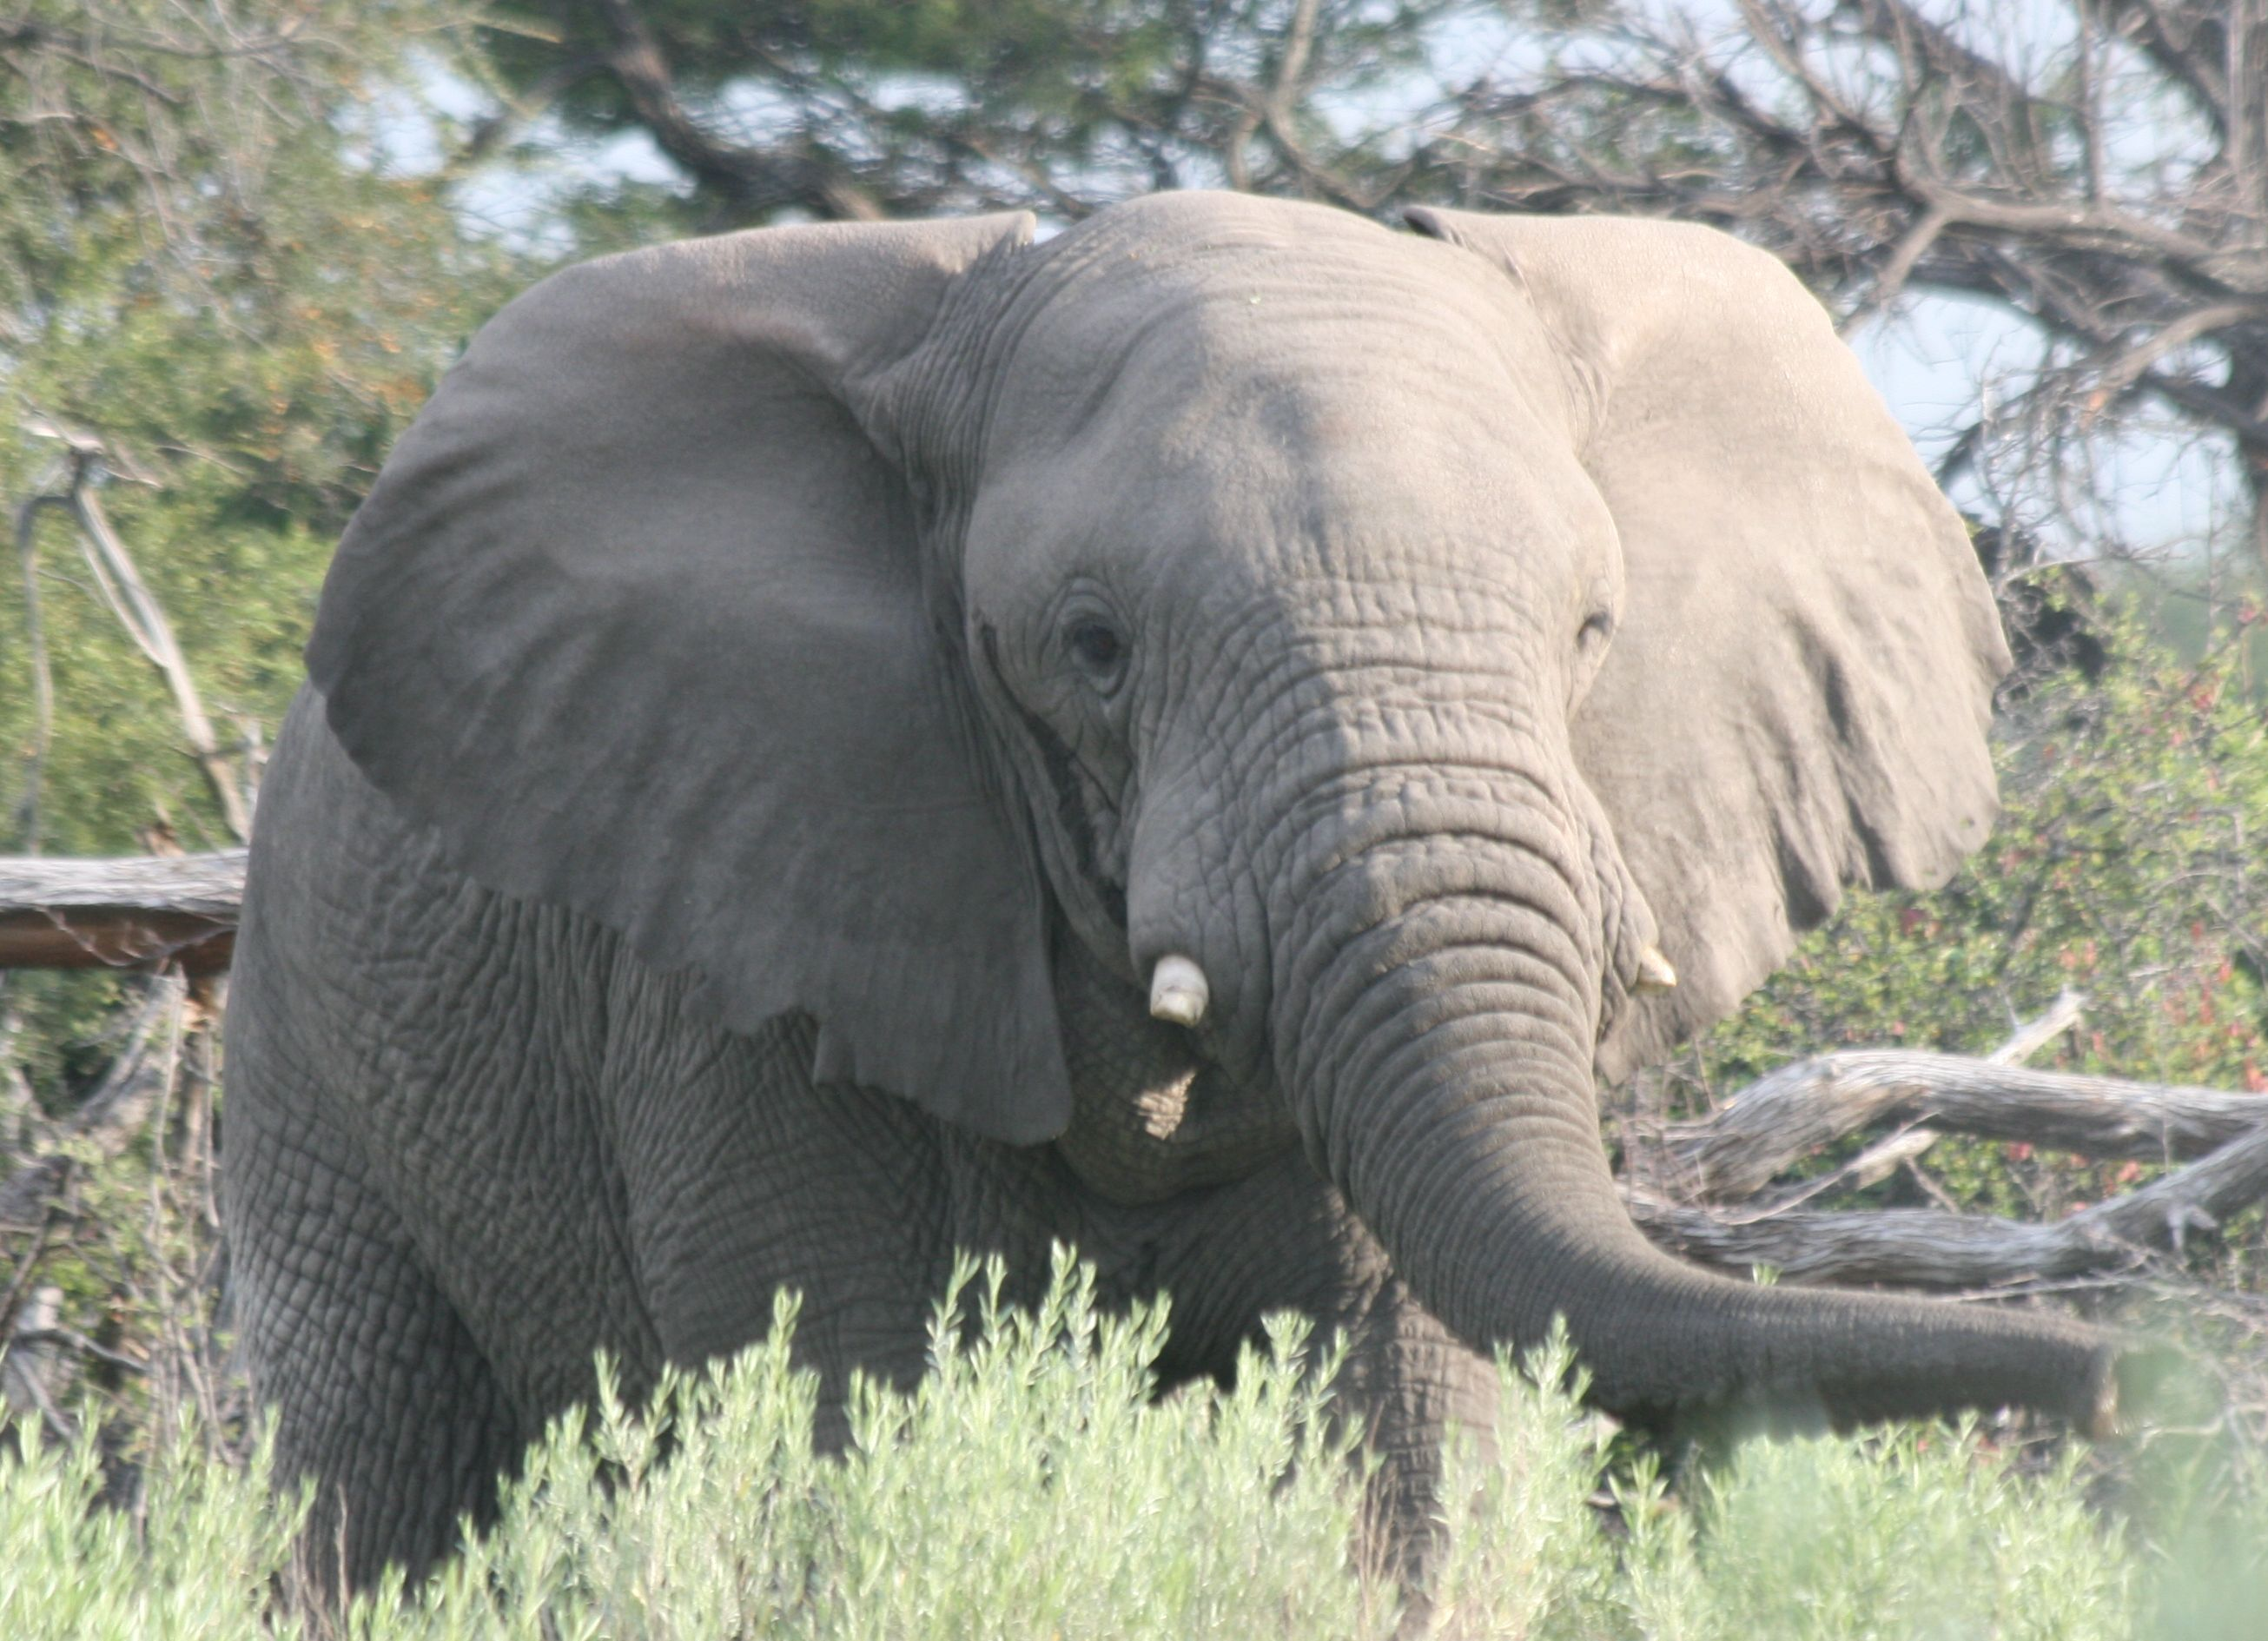

/data/vision/beery/scratch/antoine/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:892: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
WARNING ⚠️ NMS time limit 0.550s exceeded


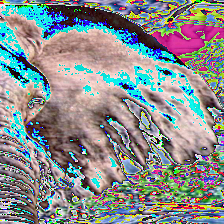

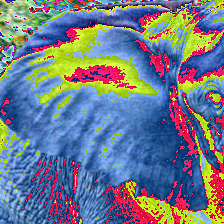

left (1741, 230, 2317, 1310) right (386, 249, 1300, 1381)


/data/vision/beery/scratch/antoine/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:892: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


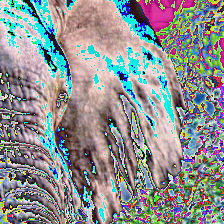

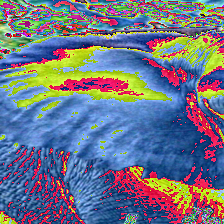

In [7]:
from PIL import Image
from IPython.display import display

dataset_dir = Path('/archive/vision/beery/animal_reid/datasets/elephants_zooniverse/images')
# Load and display the image
i +=1
image_path = dictonary['image'][i]
image = Image.open(dataset_dir / image_path)
display(image)

left, right = crop_ears(image)
if left is not None : display(T.ToPILImage()(left))
if right is not None : display(T.ToPILImage()(right))

left, right = ears_coordinates(image)
print('left', left,'right', right)

left, right = make_two_random_crop(image, left, right)
display(T.ToPILImage()(left))
display(T.ToPILImage()(right))

In [8]:
dictonary_path=Path('/data/vision/beery/scratch/antoine/CBM_reid/data_processing/data/out_apr2/image_dictonary.csv')
dictonary = pd.read_csv(dictonary_path)
dictonary = pd.concat([dictonary]*8, ignore_index=True)
dictonary

,subject_id,image,ele_id,#season,#capture,...,ele-SEEK,picture_time,preprocessed_image_path,left_ear_path,right_ear_path
0,92126812,EFA_IDU/T1000/T1000_R1/EFA_IDU_T1000_R1_IMAG00...,T1000,EFA_IDU,1,...,B00T11E8080-0000X_0S00,2015-05-22 21:31:22,/data/vision/beery/scratch/antoine/CBM_reid/pr...,NaN,NaN
1,92126813,EFA_IDU/T1000/T1000_R1/EFA_IDU_T1000_R1_IMAG00...,T1000,EFA_IDU,2,...,B00T11E8080-0000X_0S00,2015-05-22 21:33:46,/data/vision/beery/scratch/antoine/CBM_reid/pr...,/data/vision/beery/scratch/antoine/CBM_reid/pr...,/data/vision/beery/scratch/antoine/CBM_reid/pr...
2,92126815,EFA_IDU/T1001/T1001_R1/EFA_IDU_T1001_R1_IMAG00...,T1001,EFA_IDU,2,...,B00T11E____-5000X_0S00,2015-05-22 21:32:50,/data/vision/beery/scratch/antoine/CBM_reid/pr...,/data/vision/beery/scratch/antoine/CBM_reid/pr...,NaN
3,92126816,EFA_IDU/T1001/T1001_R1/EFA_IDU_T1001_R1_IMAG00...,T1001,EFA_IDU,3,...,B00T11E____-5000X_0S00,2015-05-22 21:32:51,/data/vision/beery/scratch/antoine/CBM_reid/pr...,/data/vision/beery/scratch/antoine/CBM_reid/pr...,NaN
4,92126817,EFA_IDU/T1001/T1001_R1/EFA_IDU_T1001_R1_IMAG00...,T1001,EFA_IDU,4,...,B00T11E____-5000X_0S00,2015-05-22 21:32:52,/data/vision/beery/scratch/antoine/CBM_reid/pr...,/data/vision/beery/scratch/antoine/CBM_reid/pr...,NaN
...,...,...,...,...,...,...,...,...,...,...,...
67547,92306374,EFA_IDI/F1000/F1000_R1/EFA_IDI_F1000_R1_IMAG00...,F1000,EFA_IDI,8,...,B00T11E0000-0000X0_S00,2013-08-17 16:46:01,/data/vision/beery/scratch/antoine/CBM_reid/pr...,/data/vision/beery/scratch/antoine/CBM_reid/pr...,/data/vision/beery/scratch/antoine/CBM_reid/pr...
67548,92306375,EFA_IDI/F1000/F1000_R1/EFA_IDI_F1000_R1_IMAG00...,F1000,EFA_IDI,9,...,B00T11E0000-0000X0_S00,2013-08-17 16:46:04,/data/vision/beery/scratch/antoine/CBM_reid/pr...,/data/vision/beery/scratch/antoine/CBM_reid/pr...,/data/vision/beery/scratch/antoine/CBM_reid/pr...
67549,92306418,EFA_IDI/F1000/F1000_R1/EFA_IDI_F1000_R1_IMAG00...,F1000,EFA_IDI,10,...,B00T11E0000-0000X0_S00,2013-08-17 16:46:35,/data/vision/beery/scratch/antoine/CBM_reid/pr...,NaN,/data/vision/beery/scratch/antoine/CBM_reid/pr...
67550,92306424,EFA_IDI/F1000/F1000_R1/EFA_IDI_F1000_R1_IMAG00...,F1000,EFA_IDI,11,...,B00T11E0000-0000X0_S00,2013-08-17 16:47:24,/data/vision/beery/scratch/antoine/CBM_reid/pr...,NaN,/data/vision/beery/scratch/antoine/CBM_reid/pr...


In [ ]:
# Ensure new columns exist in the DataFrame
dictonary['left_ear_path'] = None
dictonary['right_ear_path'] = None

left_ear_dir = Path('/data/vision/beery/scratch/antoine/CBM_reid/preprocessed/augmented_left_ears')
right_ear_dir = Path('/data/vision/beery/scratch/antoine/CBM_reid/preprocessed/augmented_right_ears')

from tqdm import tqdm
# Process images
for idx, image_path in tqdm(enumerate(dictonary['image'])):

    try:
        # Load the image
        image = Image.open(dataset_dir / image_path).convert('RGB')

        left_ear_coordinates, right_ear_coordinates = ears_coordinates(image)
        # Crop ears
        left_ear, right_ear = make_two_random_crop(image, left_ear_coordinates, right_ear_coordinates)

        # Convert to PIL for saving
        left_ear_pil = T.ToPILImage()(left_ear) 
        right_ear_pil = T.ToPILImage()(right_ear)

        left_ear_path = left_ear_dir / Path(image_path).parts[-4] / Path(image_path).parts[-3] / Path(image_path).parts[-1] 
        left_ear_path = left_ear_path.with_stem(f"{left_ear_path.stem}_{idx}")
        left_ear_path.parent.mkdir(parents=True, exist_ok=True)
        left_ear_pil.save(left_ear_path, format="JPEG")
        dictonary.at[idx, 'left_ear_path'] = left_ear_path

        # Save right ear if detected
        right_ear_path = right_ear_dir / Path(image_path).parts[-4] / Path(image_path).parts[-3] / Path(image_path).parts[-1]
        right_ear_path = right_ear_path.with_stem(f"{right_ear_path.stem}_{idx}")
        right_ear_path.parent.mkdir(parents=True, exist_ok=True)
        right_ear_pil.save(right_ear_path, format="JPEG")
        dictonary.at[idx, 'right_ear_path'] = right_ear_path

    except Exception as e:
        print(f"Error processing {image_path}: {e}")
        dictonary.at[idx, 'left_ear_path'] = None
        dictonary.at[idx, 'right_ear_path'] = None

dictonary.to_csv(Path('CBM_reid/data_processing/data/out_apr2/augmented_image_dictonary.csv'), index=False)

0it [00:00, ?it/s]

/data/vision/beery/scratch/antoine/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:892: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/data/vision/beery/scratch/antoine/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:892: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/data/vision/beery/scratch/antoine/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:892: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
3it [00:00, 29.73it/s]/data/vision/beery/scratch/antoine/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:892: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` in

Error processing EFA_IDU/T1000/T1000_R1/EFA_IDU_T1000_R1_IMAG0001.JPG: unsupported operand type(s) for +=: 'PosixPath' and 'str'
Error processing EFA_IDU/T1000/T1000_R1/EFA_IDU_T1000_R1_IMAG0002.JPG: unsupported operand type(s) for +=: 'PosixPath' and 'str'
Error processing EFA_IDU/T1001/T1001_R1/EFA_IDU_T1001_R1_IMAG0002.JPG: unsupported operand type(s) for +=: 'PosixPath' and 'str'
Error processing EFA_IDU/T1001/T1001_R1/EFA_IDU_T1001_R1_IMAG0003.JPG: unsupported operand type(s) for +=: 'PosixPath' and 'str'
Error processing EFA_IDU/T1001/T1001_R1/EFA_IDU_T1001_R1_IMAG0004.JPG: unsupported operand type(s) for +=: 'PosixPath' and 'str'
Error processing EFA_IDU/T1002/T1002_R1/EFA_IDU_T1002_R1_IMAG0001.JPG: unsupported operand type(s) for +=: 'PosixPath' and 'str'
Error processing EFA_IDU/T1002/T1002_R1/EFA_IDU_T1002_R1_IMAG0002.JPG: unsupported operand type(s) for +=: 'PosixPath' and 'str'
Error processing EFA_IDU/T1003/T1003_R1/EFA_IDU_T1003_R1_IMAG0001.JPG: unsupported operand type(s

/data/vision/beery/scratch/antoine/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:892: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/data/vision/beery/scratch/antoine/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:892: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/data/vision/beery/scratch/antoine/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:892: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
11it [00:00, 32.77it/s]/data/vision/beery/scratch/antoine/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:892: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` i

Error processing EFA_IDU/T1003/T1003_R1/EFA_IDU_T1003_R1_IMAG0002.JPG: unsupported operand type(s) for +=: 'PosixPath' and 'str'
Error processing EFA_IDU/T1003/T1003_R1/EFA_IDU_T1003_R1_IMAG0003.JPG: unsupported operand type(s) for +=: 'PosixPath' and 'str'
Error processing EFA_IDU/T1004/T1004_R1/EFA_IDU_T1004_R1_IMAG0001.JPG: unsupported operand type(s) for +=: 'PosixPath' and 'str'
Error processing EFA_IDU/T1004/T1004_R1/EFA_IDU_T1004_R1_IMAG0002.JPG: unsupported operand type(s) for +=: 'PosixPath' and 'str'
Error processing EFA_IDU/T1004/T1004_R1/EFA_IDU_T1004_R1_IMAG0003.JPG: unsupported operand type(s) for +=: 'PosixPath' and 'str'
Error processing EFA_IDU/T1005/T1005_R1/EFA_IDU_T1005_R1_IMAG0001.JPG: unsupported operand type(s) for +=: 'PosixPath' and 'str'
Error processing EFA_IDU/T1005/T1005_R1/EFA_IDU_T1005_R1_IMAG0002.JPG: unsupported operand type(s) for +=: 'PosixPath' and 'str'


...

/data/vision/beery/scratch/antoine/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:892: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/data/vision/beery/scratch/antoine/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:892: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/data/vision/beery/scratch/antoine/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:892: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
195it [00:09, 23.38it/s]/data/vision/beery/scratch/antoine/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:892: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` 

Error processing EFA_IDU/T1059/T1059_R1/EFA_IDU_T1059_R1_IMAG0003.JPG: unsupported operand type(s) for +=: 'PosixPath' and 'str'
Error processing EFA_IDU/T1060/T1060_R1/EFA_IDU_T1060_R1_IMAG0001.JPG: unsupported operand type(s) for +=: 'PosixPath' and 'str'
Error processing EFA_IDU/T1060/T1060_R1/EFA_IDU_T1060_R1_IMAG0002.JPG: unsupported operand type(s) for +=: 'PosixPath' and 'str'
Error processing EFA_IDU/T1060/T1060_R1/EFA_IDU_T1060_R1_IMAG0003.JPG: unsupported operand type(s) for +=: 'PosixPath' and 'str'
Error processing EFA_IDU/T1061/T1061_R1/EFA_IDU_T1061_R1_IMAG0001.JPG: unsupported operand type(s) for +=: 'PosixPath' and 'str'


/data/vision/beery/scratch/antoine/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:892: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
198it [00:09, 24.07it/s]/data/vision/beery/scratch/antoine/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:892: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
198it [00:09, 21.12it/s]


Error processing EFA_IDU/T1061/T1061_R1/EFA_IDU_T1061_R1_IMAG0002.JPG: unsupported operand type(s) for +=: 'PosixPath' and 'str'


KeyboardInterrupt: 

In [11]:
dictonary['left_ear_path']

0        /data/vision/beery/scratch/antoine/CBM_reid/pr...
1        /data/vision/beery/scratch/antoine/CBM_reid/pr...
2        /data/vision/beery/scratch/antoine/CBM_reid/pr...
3        /data/vision/beery/scratch/antoine/CBM_reid/pr...
4        /data/vision/beery/scratch/antoine/CBM_reid/pr...
                               ...                        
67547    /data/vision/beery/scratch/antoine/CBM_reid/pr...
67548    /data/vision/beery/scratch/antoine/CBM_reid/pr...
67549    /data/vision/beery/scratch/antoine/CBM_reid/pr...
67550    /data/vision/beery/scratch/antoine/CBM_reid/pr...
67551    /data/vision/beery/scratch/antoine/CBM_reid/pr...
Name: left_ear_path, Length: 67552, dtype: object

In [ ]:

dictonary.to_csv(Path('CBM_reid/data_processing/data/out_apr2/augmented_image_dictonary.csv'), index=False)




IndentationError: unexpected indent (1296959298.py, line 3)

In [ ]:
code = 'Augmented_dataset'

dataset = EleHandler(subset='IDI_6', dictonary_path=Path('CBM_reid/data_processing/data/out_apr2/augmented_image_dictonary.csv'))
train_indices, test_indices = dataset.split_perpendicular_to_elephants_and_encounters(split_sizes=[0.5,0.5], hour_delta = 0.2)

train_subset = Subset(dataset, train_indices)
test_subset = Subset(dataset, test_indices)

train_loader = DataLoader(train_subset, batch_size=92, shuffle=False)
test_loader = DataLoader(test_subset, batch_size=92, shuffle=False)

In [ ]:
ele_MD_finetuned = Backbone(model_name="MegaDescriptor", pretraining="MD_finetuned_w", experiment_code=code)
ele_MD_finetuned.unfreeze()

ele_concept = ConceptHeadTunneled(lr = 1e-5, loss=categorical_CE_loss, print_every=1, experiment_code = code, layer = CrossedHeadNN(), reset_weights=True)

ele_concept.train(train_loader, test_loader, backbone = ele_MD_finetuned, num_epochs=50, predict_ele_SEEK = True)
ele_concept.test(test_loader, backbone = ele_MD_finetuned, predict_ele_SEEK = True)

/data/vision/beery/scratch/antoine/CBM_reid/methods/backbone.py:33: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(weight_path, map_location=self.devi

Training ConceptHead for 50 epochs, reseting weights, and the backbone parameters are, True  concept head parameters are  True
Epoch 1/50 - Train Loss: 21.0160, Val Loss: 19.5398 - Train Acc: 33.91%, Val Acc: 59.20% - Train whole-code: 0.00%, Val whole-code: 0.00% - Train left ear: 33.42%, Val left ear: 53.10% - Train right ear: 25.25%, Val right ear: 47.92%


KeyboardInterrupt: 